# **Simple Linear Regression**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/campusx-official/100-days-of-machine-learning/main/day48-simple-linear-regression/placement.csv")
df.sample(5)

,cgpa,package
100,7.95,4.14
48,8.63,4.09
187,6.26,2.44
6,6.73,2.60
1,5.12,1.98


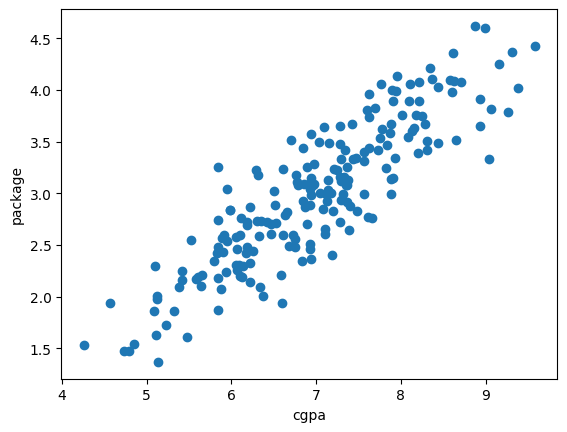

In [ ]:
plt.scatter(df['cgpa'],df['package'])
plt.xlabel("cgpa")
plt.ylabel('package')
plt.show()

In [ ]:
X = df.iloc[:,0:1].values
y = df.iloc[:,1].values

In [ ]:
y

array([3.26, 1.98, 3.25, 3.67, 3.57, 2.99, 2.6 , 2.48, 2.31, 3.51, 1.86,
       2.6 , 3.65, 2.89, 3.42, 3.23, 2.35, 2.09, 2.98, 2.83, 3.16, 2.93,
       2.3 , 2.48, 2.71, 3.65, 3.42, 2.16, 2.24, 3.49, 3.26, 3.89, 3.08,
       2.73, 3.42, 2.87, 2.84, 2.43, 4.36, 3.33, 4.02, 2.7 , 2.54, 2.76,
       1.86, 3.58, 2.26, 3.26, 4.09, 4.62, 4.43, 3.79, 4.11, 2.61, 3.09,
       3.39, 2.74, 1.94, 3.09, 3.31, 2.19, 1.61, 2.09, 4.25, 2.92, 3.81,
       1.63, 2.89, 2.99, 2.94, 2.35, 3.34, 3.62, 4.03, 3.44, 3.28, 3.15,
       4.6 , 2.21, 3.  , 3.44, 2.2 , 2.17, 3.49, 1.53, 1.48, 2.77, 3.55,
       1.48, 2.72, 2.66, 2.14, 4.  , 3.08, 2.42, 2.79, 2.61, 2.84, 3.83,
       3.24, 4.14, 3.52, 1.37, 3.  , 3.74, 2.82, 2.19, 2.59, 3.54, 4.06,
       3.76, 2.25, 4.1 , 2.37, 1.87, 4.21, 3.33, 2.99, 2.88, 2.65, 1.73,
       3.02, 2.01, 2.3 , 2.31, 3.16, 2.6 , 3.11, 3.34, 3.12, 2.49, 2.01,
       2.48, 2.58, 2.83, 2.6 , 2.1 , 3.13, 3.89, 2.4 , 3.15, 3.18, 3.04,
       1.54, 2.42, 2.18, 2.46, 2.21, 3.4 , 3.67, 2.

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [ ]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(160, 1)
(40, 1)
(160,)
(40,)


In [ ]:
class LinearRegression:

  def __init__(self):
    self.m = None
    self.b = None

  def fit(self,X_train,y_train):
    num,den=0,0
    for i in range(X_train.shape[0]):
      num=num+((X_train[i]-X_train.mean())*(y_train[i]-y_train.mean()))
      den=den+((X_train[i]-X_train.mean())*(X_train[i]-X_train.mean()))

    self.m=num/den

    self.b=y_train.mean()-(self.m*X_train.mean())

  def predict(self,X_test):
    return self.m*X_test+self.b

  def show(self):
    print("The Coefficient Value is : ",self.m)
    print("The Intercept Value is : ", self.b)

In [ ]:
lr=LinearRegression()

In [ ]:
lr.fit(X_train,y_train)

In [ ]:
lr.show()

The Coefficient Value is :  [0.55795197]
The Intercept Value is :  [-0.89611192]


In [ ]:
y_pred=lr.predict(X_test)
lr.predict(X_test[0].reshape(1,1))

array([[3.89111601]])

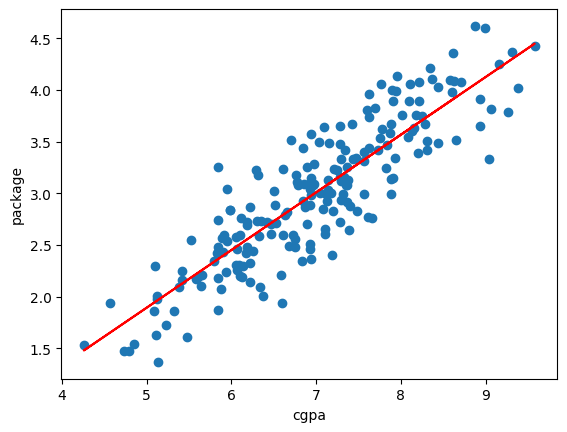

In [ ]:
plt.scatter(df['cgpa'],df['package'])
plt.plot(X_train,lr.predict(X_train),color='red')
plt.xlabel("cgpa")
plt.ylabel('package')
plt.show()

# **Multiple Linear Regression**

In [ ]:
from sklearn.datasets import load_diabetes

In [ ]:
X,y=load_diabetes(return_X_y=True)

In [ ]:
from sklearn.datasets import load_diabetes
import pandas as pd

# Load the dataset
diabetes = load_diabetes()

# Create DataFrame
df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
df["target"] = diabetes.target

df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [ ]:
import plotly.express as px

fig = px.scatter_matrix(
    df,
    dimensions=df.columns[:-1],   # all features except target
    color="target",
    title="Scatter Matrix of Diabetes Dataset"
)

fig.show()

In [ ]:
X = df.drop("target", axis=1).values
y = df["target"].values

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=2)

In [ ]:
class MultipleLinearRegression:

  def __init__(self):
    self.coef_ = None
    self.intercept_ = None

  def fit(self,X_train,y_train):
    X_train = np.insert(X_train,0,1,axis=1)
    betas = np.linalg.inv(np.dot(X_train.T,X_train)).dot(X_train.T).dot(y_train)
    self.intercept_ = betas[0]
    self.coef_ = betas[1:]

  def predict(self,X_test):
    y_pred = np.dot(X_test,self.coef_) + self.intercept_
    return y_pred

  def show(self):
    print("The Coefficient Value is : ",self.coef_)
    print("The Intercept Value is : ", self.intercept_)

In [ ]:
mlr = MultipleLinearRegression()

In [ ]:
mlr.fit(X_train,y_train)

In [ ]:
mlr.show()

The Coefficient Value is :  [  -9.15865318 -205.45432163  516.69374454  340.61999905 -895.5520019
  561.22067904  153.89310954  126.73139688  861.12700152   52.42112238]
The Intercept Value is :  151.88331005254165


In [ ]:
mlr.predict(X_test[0])

np.float64(154.12138809538368)